In [4]:
# ETAPA 1 - IMPORTAÇÃO DAS BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


# ETAPA 2 - CARREGAMENTO DOS 7 CSVs EM UM ÚNICO DATAFRAME

arquivos = [
    "doacoes-recebidas2020.csv",
    "doacoes-recebidas2021.csv",
    "doacoes-recebidas2022.csv",
    "doacoes-recebidas2023.csv",
    "doacoes-recebidas2024.csv",
    "doacoes-recebidas2025.csv",
    "doacoes-recebidas2026.csv"
]

lista_dfs = []

for arquivo in arquivos:
    df = pd.read_csv(
        arquivo,
        sep=";",
        encoding="latin-1"
    )
    lista_dfs.append(df)

df_total = pd.concat(lista_dfs, ignore_index=True)

print("Dimensão do DataFrame consolidado:", df_total.shape)
df_total.head()

Dimensão do DataFrame consolidado: (3431, 24)


,NR_ANO_STATUS,CD_UG,NR_MES,DS_UNIDADE_GESTORA,CD_GESTAO,DS_GESTAO,CD_CONTA_CONTABIL,DS_CONTA_CONTABIL,CD_CONTA_CORRENTE,NR_ESFERA,...,CD_PROGRAMA,CD_PROJETO,CD_SUBTITULO,CD_FONTE_RECURSO,DS_FONTE_RECURSO,CD_NATUREZA,CD_CATEGORIA,VL_CREDITO,VL_DEBITO,ï»¿NR_ANO_STATUS
0,2020.0,90101,1,CASA CIVIL DO DISTRITO FEDERAL ...,1,TESOURO ...,451211301,DOAÇÃO RECEBIDA - BENS MÓVEIS ...,35,0,...,0,0,0,0,CONV. ORGAOS NAO PER. AO GDF ...,0,0,"3680,32","3680,32",NaN
1,2020.0,90101,11,CASA CIVIL DO DISTRITO FEDERAL ...,1,TESOURO ...,451211301,DOAÇÃO RECEBIDA - BENS MÓVEIS ...,35,0,...,0,0,0,0,CONV. ORGAOS NAO PER. AO GDF ...,0,0,113982,0,NaN
2,2020.0,90101,2,CASA CIVIL DO DISTRITO FEDERAL ...,1,TESOURO ...,451211301,DOAÇÃO RECEBIDA - BENS MÓVEIS ...,42,0,...,0,0,0,0,CONV. ORGAOS NAO PER. AO GDF ...,0,0,"57473,41",0,NaN
3,2020.0,100101,1,GABINETE DO VICE-GOVERNADOR DO DISTRITO FEDERA...,1,TESOURO ...,451211301,DOAÇÃO RECEBIDA - BENS MÓVEIS ...,42,0,...,0,0,0,1,NaN,0,0,"92928,06",0,NaN
4,2020.0,100101,2,GABINETE DO VICE-GOVERNADOR DO DISTRITO FEDERA...,1,TESOURO ...,451211301,DOAÇÃO RECEBIDA - BENS MÓVEIS ...,52,0,...,0,0,0,0,CONV. ORGAOS NAO PER. AO GDF ...,0,0,74440,0,NaN


In [5]:
# ETAPA 3 - PRÉ-PROCESSAMENTO DOS DADOS

# Corrige possível problema de BOM no nome da coluna de ano
if "ï»¿NR_ANO_STATUS" in df_total.columns:
    df_total["NR_ANO_STATUS"] = df_total["NR_ANO_STATUS"].fillna(
        df_total["ï»¿NR_ANO_STATUS"]
    )
    df_total = df_total.drop(columns=["ï»¿NR_ANO_STATUS"])


def converter_valor(valor):
    """
    Converte valores financeiros para float.
    Trata formatos como:
    - 1.234,56
    - 1234,56
    - 1,234.56
    - 1234.56
    """
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()
    valor = valor.replace("R$", "").replace(" ", "")

    valor = "".join(c for c in valor if c.isdigit() or c in [",", ".", "-"])

    if "," in valor and "." in valor:
        if valor.rfind(",") > valor.rfind("."):
            valor = valor.replace(".", "").replace(",", ".")
        else:
            valor = valor.replace(",", "")
    elif "," in valor:
        valor = valor.replace(".", "").replace(",", ".")

    return pd.to_numeric(valor, errors="coerce")


df_total["VL_CREDITO"] = df_total["VL_CREDITO"].apply(converter_valor)

df_total["NR_ANO_STATUS"] = pd.to_numeric(
    df_total["NR_ANO_STATUS"], errors="coerce"
).astype("Int64")

df_total["NR_MES"] = pd.to_numeric(
    df_total["NR_MES"], errors="coerce"
).astype("Int64")

df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3431 entries, 0 to 3430
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NR_ANO_STATUS            3431 non-null   Int64  
 1   CD_UG                    3431 non-null   int64  
 2   NR_MES                   3431 non-null   Int64  
 3   DS_UNIDADE_GESTORA       3431 non-null   object 
 4   CD_GESTAO                3431 non-null   int64  
 5   DS_GESTAO                3431 non-null   object 
 6   CD_CONTA_CONTABIL        3431 non-null   int64  
 7   DS_CONTA_CONTABIL        3431 non-null   object 
 8   CD_CONTA_CORRENTE        3431 non-null   object 
 9   NR_ESFERA                3431 non-null   int64  
 10  DS_ESFERA                3431 non-null   object 
 11  CD_UNIDADE_ORCAMENTARIA  3431 non-null   int64  
 12  CD_FUNCAO                3431 non-null   int64  
 13  CD_SUB_FUNCAO            3431 non-null   int64  
 14  CD_PROGRAMA             

In [6]:
# ETAPA 4 - VERIFICAÇÃO DE VALORES NULOS

df_total.isnull().sum()

,0
NR_ANO_STATUS,0
CD_UG,0
NR_MES,0
DS_UNIDADE_GESTORA,0
CD_GESTAO,0
DS_GESTAO,0
CD_CONTA_CONTABIL,0
DS_CONTA_CONTABIL,0
CD_CONTA_CORRENTE,0
NR_ESFERA,0



**Interpretação da verificação de valores nulos:**  
A verificação de valores nulos mostra que praticamente todas as colunas estão completas.
Após a correção da coluna de ano, `NR_ANO_STATUS` não apresenta mais valores ausentes.
Foi identificado apenas **1 valor nulo** na coluna `DS_FONTE_RECURSO`, o que representa uma ocorrência isolada dentro do conjunto de 3431 registros.
Como essa coluna não é essencial para os gráficos principais da análise, que utilizam `NR_ANO_STATUS`, `NR_MES`, `DS_UNIDADE_GESTORA`, `DS_CONTA_CONTABIL` e `VL_CREDITO`, esse valor ausente não compromete a EDA.

In [7]:
df_total["DS_FONTE_RECURSO"] = df_total["DS_FONTE_RECURSO"].fillna("Não informado")

df_total.isnull().sum()

,0
NR_ANO_STATUS,0
CD_UG,0
NR_MES,0
DS_UNIDADE_GESTORA,0
CD_GESTAO,0
DS_GESTAO,0
CD_CONTA_CONTABIL,0
DS_CONTA_CONTABIL,0
CD_CONTA_CORRENTE,0
NR_ESFERA,0


In [8]:
# VALOR LÍQUIDO DAS DOAÇÕES POR ANO
# VL_LIQUIDO = VL_CREDITO - VL_DEBITO

df_total["VL_DEBITO"] = df_total["VL_DEBITO"].apply(converter_valor)
df_total["VL_DEBITO"] = df_total["VL_DEBITO"].fillna(0)

df_total["VL_LIQUIDO"] = df_total["VL_CREDITO"] - df_total["VL_DEBITO"]

valor_liquido_por_ano = (
    df_total
    .groupby("NR_ANO_STATUS", as_index=False)
    .agg(
        total_credito=("VL_CREDITO", "sum"),
        total_debito=("VL_DEBITO", "sum"),
        valor_liquido=("VL_LIQUIDO", "sum"),
        quantidade_registros=("VL_LIQUIDO", "count")
    )
    .sort_values("NR_ANO_STATUS")
)

valor_liquido_por_ano

,NR_ANO_STATUS,total_credito,total_debito,valor_liquido,quantidade_registros
0,2020,2.398333e+08,43082681.02,1.967506e+08,571
1,2021,1.285765e+08,14441144.42,1.141354e+08,567
2,2022,1.172063e+08,12224528.46,1.049818e+08,513
3,2023,1.863702e+08,30709207.59,1.556610e+08,563
4,2024,2.096960e+08,7477895.18,2.022181e+08,572
5,2025,1.728007e+08,99480038.79,7.332068e+07,595
6,2026,1.620232e+08,75197378.77,8.682579e+07,50


In [9]:
valor_liquido_por_ano_formatado = valor_liquido_por_ano.copy()

for coluna in ["total_credito", "total_debito", "valor_liquido"]:
    valor_liquido_por_ano_formatado[coluna] = valor_liquido_por_ano_formatado[coluna].map(
        lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )

valor_liquido_por_ano_formatado

,NR_ANO_STATUS,total_credito,total_debito,valor_liquido,quantidade_registros
0,2020,"R$ 239.833.256,26","R$ 43.082.681,02","R$ 196.750.575,24",571
1,2021,"R$ 128.576.546,93","R$ 14.441.144,42","R$ 114.135.402,51",567
2,2022,"R$ 117.206.283,99","R$ 12.224.528,46","R$ 104.981.755,53",513
3,2023,"R$ 186.370.185,86","R$ 30.709.207,59","R$ 155.660.978,27",563
4,2024,"R$ 209.695.968,55","R$ 7.477.895,18","R$ 202.218.073,37",572
5,2025,"R$ 172.800.720,53","R$ 99.480.038,79","R$ 73.320.681,74",595
6,2026,"R$ 162.023.171,33","R$ 75.197.378,77","R$ 86.825.792,56",50


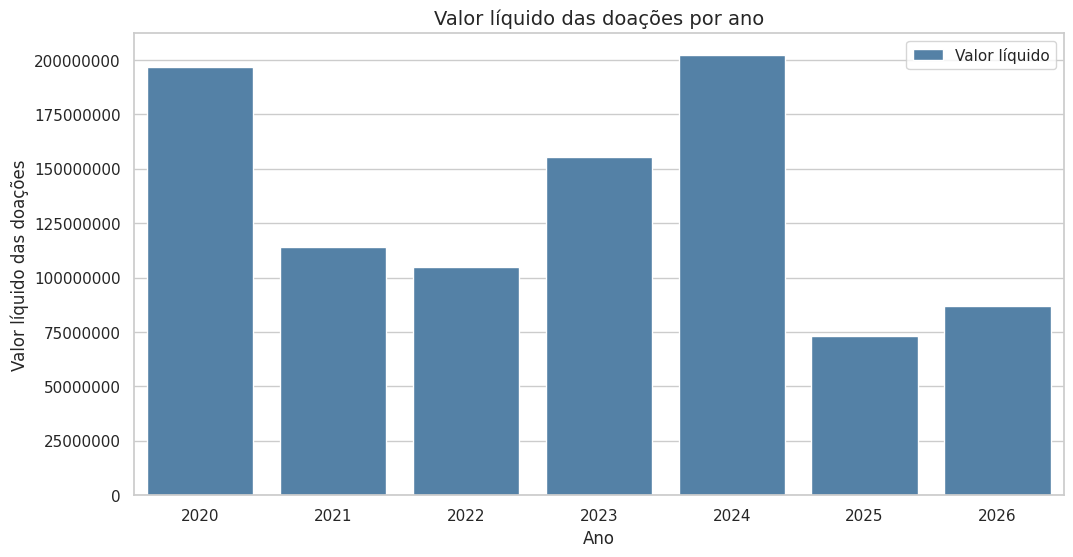

In [10]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=valor_liquido_por_ano,
    x="NR_ANO_STATUS",
    y="valor_liquido",
    color="steelblue",
    label="Valor líquido"
)

plt.title("Valor líquido das doações por ano")
plt.xlabel("Ano")
plt.ylabel("Valor líquido das doações")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

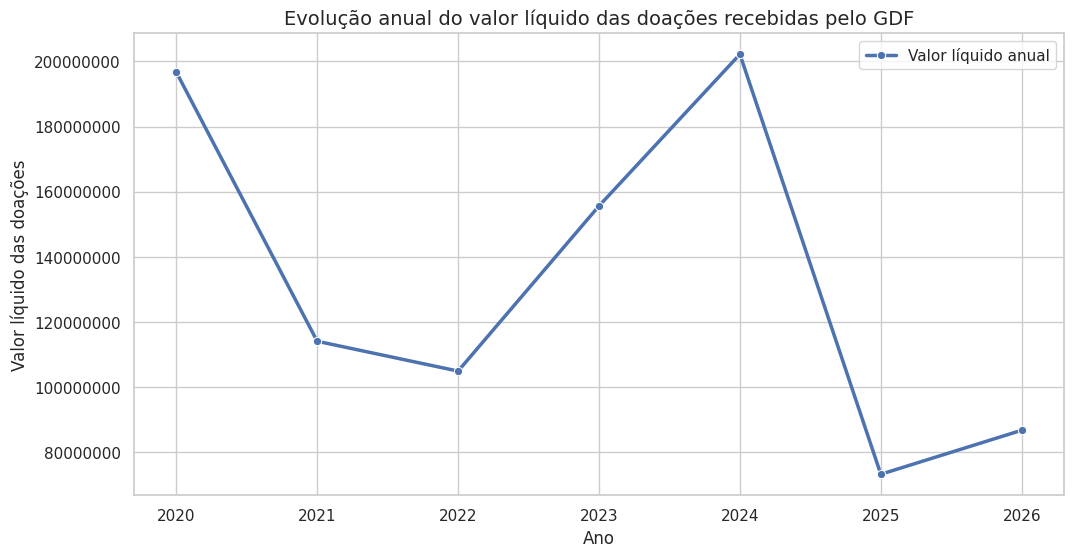


**Interpretação:**
O gráfico mostra a evolução anual do **valor líquido** das doações recebidas pelo Governo do Distrito Federal entre 2020 e 2026.
O valor líquido foi calculado pela diferença entre `VL_CREDITO` e `VL_DEBITO`, permitindo considerar estornos, ajustes ou correções contábeis.
Assim, a análise evita superestimar o volume financeiro das doações e apresenta uma visão mais realista do valor efetivamente incorporado ao patrimônio público em cada ano.


In [11]:
# ETAPA 5.1 - GRÁFICO DE LINHA
# Evolução anual da soma total de VL_LIQUIDO

evolucao_anual = (
    df_total
    .groupby("NR_ANO_STATUS", as_index=False)["VL_LIQUIDO"]
    .sum()
    .sort_values("NR_ANO_STATUS")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=evolucao_anual,
    x="NR_ANO_STATUS",
    y="VL_LIQUIDO",
    marker="o",
    linewidth=2.5,
    label="Valor líquido anual"
)

plt.title("Evolução anual do valor líquido das doações recebidas pelo GDF")
plt.xlabel("Ano")
plt.ylabel("Valor líquido das doações")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

display(Markdown("""
**Interpretação:**
O gráfico mostra a evolução anual do **valor líquido** das doações recebidas pelo Governo do Distrito Federal entre 2020 e 2026.
O valor líquido foi calculado pela diferença entre `VL_CREDITO` e `VL_DEBITO`, permitindo considerar estornos, ajustes ou correções contábeis.
Assim, a análise evita superestimar o volume financeiro das doações e apresenta uma visão mais realista do valor efetivamente incorporado ao patrimônio público em cada ano.
"""))

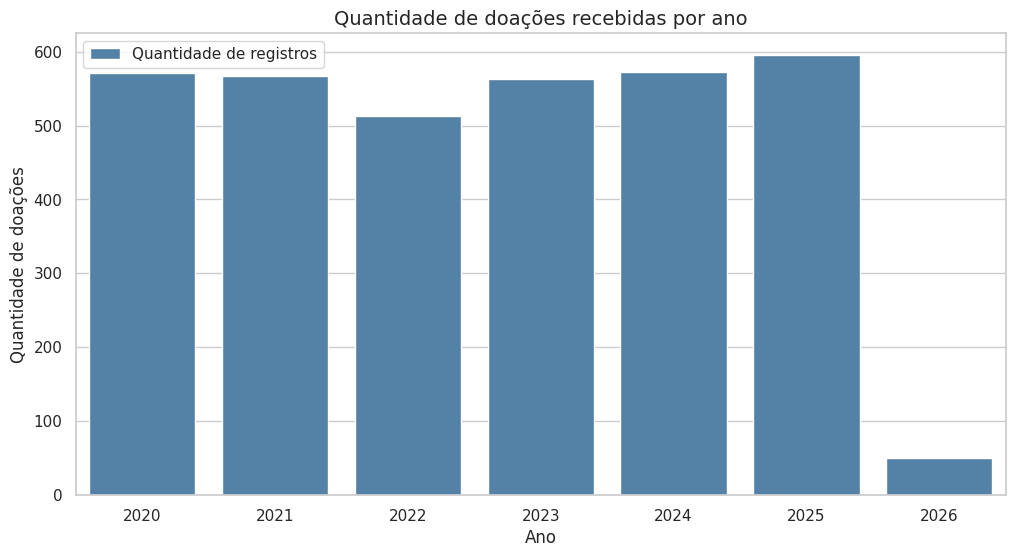


**Interpretação:**
Este gráfico apresenta a quantidade de registros de doações por ano, independentemente do valor financeiro de cada uma.
Ele complementa o gráfico de valor líquido, pois permite comparar se as variações financeiras estão associadas ao aumento ou à redução no número de doações.
Assim, é possível identificar anos com muitos registros de baixo valor e anos com poucos registros, mas com alto impacto financeiro.


In [12]:
# ETAPA 5.2 - GRÁFICO DE BARRAS
# Quantidade de doações por ano

contagem_anual = (
    df_total
    .groupby("NR_ANO_STATUS")
    .size()
    .reset_index(name="Quantidade de doações")
    .sort_values("NR_ANO_STATUS")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=contagem_anual,
    x="NR_ANO_STATUS",
    y="Quantidade de doações",
    color="steelblue",
    label="Quantidade de registros"
)

plt.title("Quantidade de doações recebidas por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de doações")
plt.legend()
plt.show()

display(Markdown("""
**Interpretação:**
Este gráfico apresenta a quantidade de registros de doações por ano, independentemente do valor financeiro de cada uma.
Ele complementa o gráfico de valor líquido, pois permite comparar se as variações financeiras estão associadas ao aumento ou à redução no número de doações.
Assim, é possível identificar anos com muitos registros de baixo valor e anos com poucos registros, mas com alto impacto financeiro.
"""))

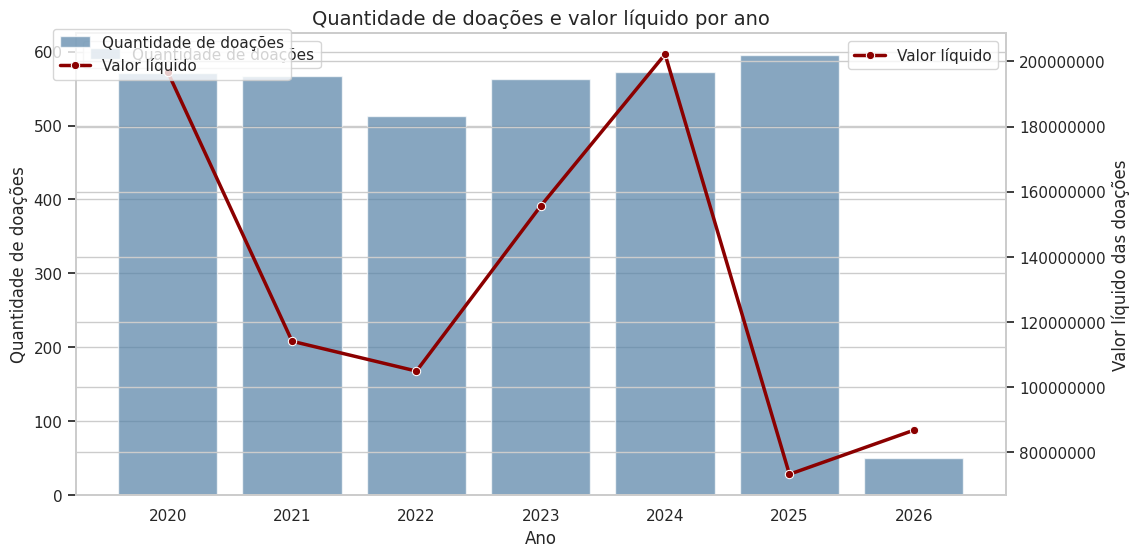

In [13]:
# GRÁFICO COMPARATIVO
# Quantidade de doações e valor líquido por ano

resumo_anual = (
    df_total
    .groupby("NR_ANO_STATUS")
    .agg(
        quantidade_doacoes=("VL_LIQUIDO", "count"),
        valor_liquido=("VL_LIQUIDO", "sum")
    )
    .reset_index()
    .sort_values("NR_ANO_STATUS")
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=resumo_anual,
    x="NR_ANO_STATUS",
    y="quantidade_doacoes",
    color="steelblue",
    alpha=0.7,
    ax=ax1,
    label="Quantidade de doações"
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de doações")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()

sns.lineplot(
    data=resumo_anual,
    x=range(len(resumo_anual)),
    y="valor_liquido",
    color="darkred",
    marker="o",
    linewidth=2.5,
    ax=ax2,
    label="Valor líquido"
)

ax2.set_ylabel("Valor líquido das doações")
ax2.ticklabel_format(style="plain", axis="y")

plt.title("Quantidade de doações e valor líquido por ano")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

In [14]:
# PADRONIZAÇÃO DAS NATUREZAS CONTÁBEIS
# Corrige categorias duplicadas por problema de codificação

mapa_naturezas = {
    "DOAÃÃO RECEBIDA - BENS MÃVEIS": "DOAÇÃO RECEBIDA - BENS MÓVEIS",
    "DOAÃÃO RECEBIDA DE BENS MÃVEIS": "DOAÇÃO RECEBIDA - BENS MÓVEIS",
    "DOAÃÃO RECEBIDA DE BENS IMÃVEIS": "DOAÇÃO RECEBIDA DE BENS IMÓVEIS",
    "DOAÃÃO RECEBIDA - MATERIAL DE DISTRIBUIÃÃO GRATUITA": "DOAÇÃO RECEBIDA - MATERIAL DE DISTRIBUIÇÃO GRATUITA",
    "DOAÃÃES RECEBIDAS": "DOAÇÕES RECEBIDAS",
    "DOAÃÃES RECEBIDAS COVID-19": "DOAÇÕES RECEBIDAS COVID-19"
}

df_total["DS_CONTA_CONTABIL"] = (
    df_total["DS_CONTA_CONTABIL"]
    .astype(str)
    .str.strip()
    .replace(mapa_naturezas)
)

In [15]:
# LIMPEZA DE TEXTOS PARA EVITAR ERROS DE FONTE NOS GRÁFICOS

colunas_texto = [
    "DS_UNIDADE_GESTORA",
    "DS_CONTA_CONTABIL",
    "DS_FONTE_RECURSO"
]

for coluna in colunas_texto:
    if coluna in df_total.columns:
        df_total[coluna] = (
            df_total[coluna]
            .astype(str)
            .str.encode("latin-1", errors="ignore")
            .str.decode("utf-8", errors="ignore")
            .str.strip()
        )

In [16]:
df_total["DS_CONTA_CONTABIL"].drop_duplicates().sort_values().tolist()

['DOAES RECEBIDAS',
 'DOAES RECEBIDAS COVID-19',
 'DOAO RECEBIDA - BENS DE CONSUMO',
 'DOAO RECEBIDA - BENS MVEIS',
 'DOAO RECEBIDA - MATERIAL DE DISTRIBUIO GRATUITA',
 'DOAO RECEBIDA DE BENS IMVEIS']

In [17]:
# PADRONIZAÇÃO FINAL DAS CATEGORIAS DE DOAÇÃO

mapa_naturezas_final = {
    "DOAES RECEBIDAS": "DOAÇÕES RECEBIDAS",
    "DOAES RECEBIDAS COVID-19": "DOAÇÕES RECEBIDAS COVID-19",
    "DOAO RECEBIDA - BENS DE CONSUMO": "DOAÇÃO RECEBIDA - BENS DE CONSUMO",
    "DOAO RECEBIDA - MATERIAL DE DISTRIBUIO GRATUITA": "DOAÇÃO RECEBIDA - MATERIAL DE DISTRIBUIÇÃO GRATUITA",
    "DOAO RECEBIDA DE BENS IMVEIS": "DOAÇÃO RECEBIDA DE BENS IMÓVEIS",
    "DOAO RECEBIDA DE BENS MVEIS": "DOAÇÃO RECEBIDA - BENS MÓVEIS"
}

df_total["DS_CONTA_CONTABIL"] = (
    df_total["DS_CONTA_CONTABIL"]
    .astype(str)
    .str.strip()
    .replace(mapa_naturezas_final)
)

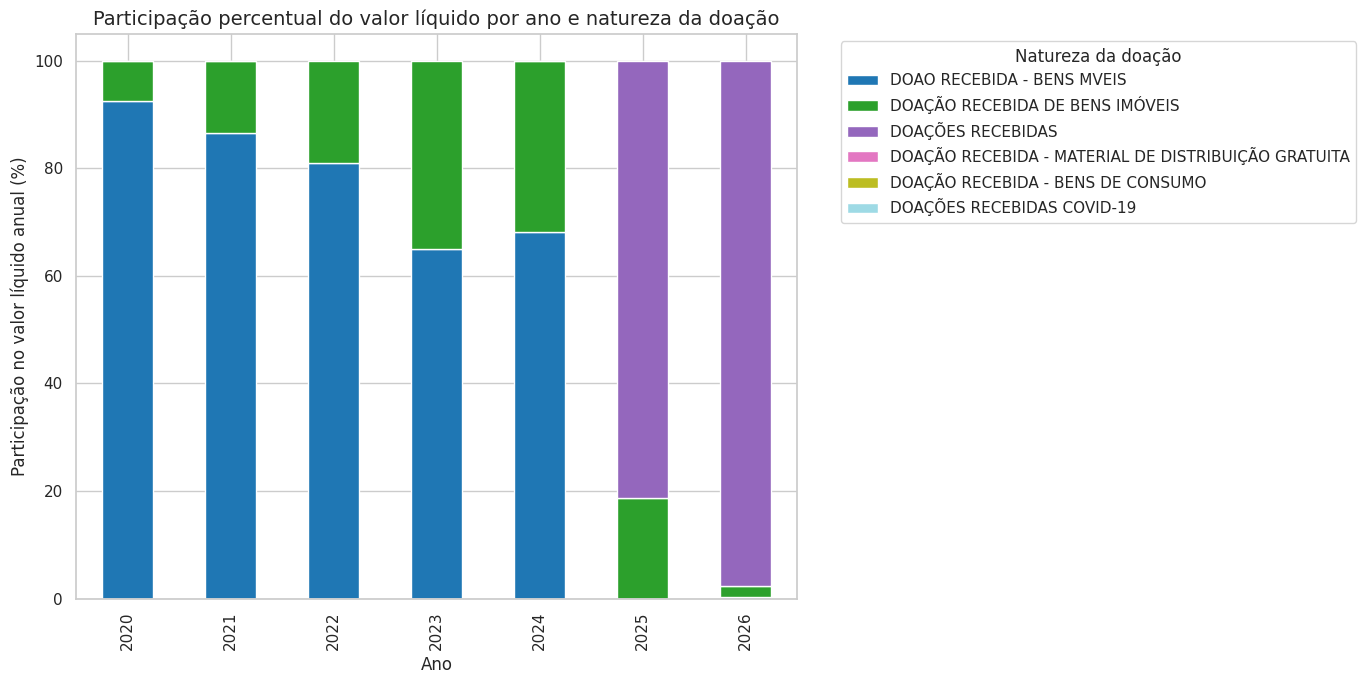


**Interpretação:**
Neste gráfico, os valores foram representados em termos percentuais usando o **valor líquido das doações**, calculado como `VL_CREDITO - VL_DEBITO`.
Essa abordagem permite visualizar a participação de cada natureza de doação no resultado financeiro líquido de cada ano, considerando possíveis estornos, ajustes ou correções contábeis.
Como as categorias de **bens móveis** e **bens imóveis** concentram grande parte do volume financeiro, a versão percentual facilita a visualização das naturezas com menor participação sem alterar os dados originais.


In [18]:
# ETAPA 5.3.3 - GRÁFICO DE BARRAS EMPILHADAS PERCENTUAIS
# Participação do VL_LIQUIDO por ano e natureza da doação

tabela_natureza = (
    df_total
    .pivot_table(
        index="NR_ANO_STATUS",
        columns="DS_CONTA_CONTABIL",
        values="VL_LIQUIDO",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

tabela_natureza_percentual = tabela_natureza.div(
    tabela_natureza.sum(axis=1).replace(0, np.nan),
    axis=0
) * 100

ordem_colunas = tabela_natureza.sum().sort_values(ascending=False).index
tabela_natureza_percentual = tabela_natureza_percentual[ordem_colunas]

tabela_natureza_percentual.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="tab20"
)

plt.title("Participação percentual do valor líquido por ano e natureza da doação")
plt.xlabel("Ano")
plt.ylabel("Participação no valor líquido anual (%)")
plt.legend(title="Natureza da doação", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(Markdown("""
**Interpretação:**
Neste gráfico, os valores foram representados em termos percentuais usando o **valor líquido das doações**, calculado como `VL_CREDITO - VL_DEBITO`.
Essa abordagem permite visualizar a participação de cada natureza de doação no resultado financeiro líquido de cada ano, considerando possíveis estornos, ajustes ou correções contábeis.
Como as categorias de **bens móveis** e **bens imóveis** concentram grande parte do volume financeiro, a versão percentual facilita a visualização das naturezas com menor participação sem alterar os dados originais.
"""))

In [19]:
# VERIFICAÇÃO: EXISTEM DOAÇÕES EM DINHEIRO?

termos_dinheiro = [
    "DINHEIRO",
    "NUMERARIO",
    "NUMERÁRIO",
    "RECURSO",
    "FINANCEIRO",
    "FINANCEIRA",
    "CAIXA",
    "BANCO",
    "TRANSFERENCIA",
    "TRANSFERÊNCIA"
]

padrao = "|".join(termos_dinheiro)

possiveis_doacoes_dinheiro = df_total[
    df_total["DS_CONTA_CONTABIL"]
    .astype(str)
    .str.upper()
    .str.contains(padrao, na=False)
]

possiveis_doacoes_dinheiro[[
    "NR_ANO_STATUS",
    "NR_MES",
    "DS_UNIDADE_GESTORA",
    "DS_CONTA_CONTABIL",
    "VL_CREDITO"
]].sort_values("VL_CREDITO", ascending=False)

,NR_ANO_STATUS,NR_MES,DS_UNIDADE_GESTORA,DS_CONTA_CONTABIL,VL_CREDITO


In [20]:
resumo_naturezas = (
    df_total
    .groupby("DS_CONTA_CONTABIL", as_index=False)
    .agg(
        quantidade=("VL_CREDITO", "count"),
        volume_total=("VL_CREDITO", "sum")
    )
    .sort_values("volume_total", ascending=False)
)

resumo_naturezas

,DS_CONTA_CONTABIL,quantidade,volume_total
0,DOAO RECEBIDA - BENS MVEIS,3155,7.430809e+08
4,DOAÇÕES RECEBIDAS,107,2.487726e+08
3,DOAÇÃO RECEBIDA DE BENS IMÓVEIS,134,2.228632e+08
1,DOAÇÃO RECEBIDA - BENS DE CONSUMO,16,1.312000e+06
2,DOAÇÃO RECEBIDA - MATERIAL DE DISTRIBUIÇÃO GRA...,18,4.774139e+05
5,DOAÇÕES RECEBIDAS COVID-19,1,1.000000e-02



**Interpretação das naturezas das doações:**  
Após a padronização dos nomes das categorias, observa-se que as doações estão concentradas principalmente em **bens móveis**, tanto em quantidade de registros quanto em volume financeiro.
Também se destacam as categorias **doações recebidas** e **bens imóveis**, que apresentam valores financeiros relevantes no período analisado.
Não foram encontradas categorias classificadas explicitamente como doação em dinheiro, numerário, depósito, banco ou transferência financeira.
Assim, a base analisada indica predominância de doações patrimoniais e materiais.

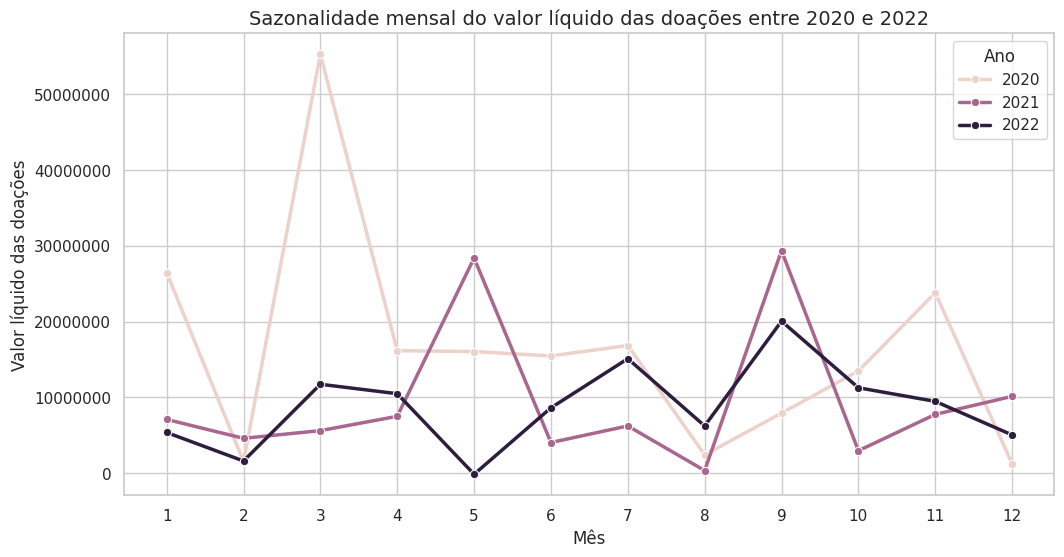


**Interpretação:**
Este gráfico compara o comportamento mensal do **valor líquido** das doações em 2020, 2021 e 2022, período associado aos efeitos da pandemia.
A visualização permite identificar meses de maior concentração financeira líquida e verificar se houve sazonalidade ou picos específicos.
Como o cálculo considera `VL_CREDITO - VL_DEBITO`, a análise reduz o risco de superestimar os valores mensais quando há estornos, ajustes ou correções contábeis.


In [21]:
# ETAPA 5.4 - GRÁFICO DE LINHAS MÚLTIPLAS
# Sazonalidade mensal do valor líquido das doações em 2020, 2021 e 2022

df_pandemia = df_total[df_total["NR_ANO_STATUS"].isin([2020, 2021, 2022])]

sazonalidade = (
    df_pandemia
    .groupby(["NR_ANO_STATUS", "NR_MES"], as_index=False)["VL_LIQUIDO"]
    .sum()
    .sort_values(["NR_ANO_STATUS", "NR_MES"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=sazonalidade,
    x="NR_MES",
    y="VL_LIQUIDO",
    hue="NR_ANO_STATUS",
    marker="o",
    linewidth=2.5
)

plt.title("Sazonalidade mensal do valor líquido das doações entre 2020 e 2022")
plt.xlabel("Mês")
plt.ylabel("Valor líquido das doações")
plt.xticks(range(1, 13))
plt.legend(title="Ano")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

display(Markdown("""
**Interpretação:**
Este gráfico compara o comportamento mensal do **valor líquido** das doações em 2020, 2021 e 2022, período associado aos efeitos da pandemia.
A visualização permite identificar meses de maior concentração financeira líquida e verificar se houve sazonalidade ou picos específicos.
Como o cálculo considera `VL_CREDITO - VL_DEBITO`, a análise reduz o risco de superestimar os valores mensais quando há estornos, ajustes ou correções contábeis.
"""))

In [22]:
# LIMPEZA CORRETA DE TEXTOS PARA GRAFICOS
# Mantem as letras e apenas remove os acentos

import unicodedata
import re

def corrigir_texto_para_grafico(texto):
    texto = str(texto)

    # Tenta corrigir casos de texto mal decodificado, como SAÃDE
    try:
        texto = texto.encode("latin-1").decode("utf-8")
    except:
        pass

    # Remove acentos preservando as letras
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))

    # Remove apenas caracteres de controle ou símbolos muito estranhos
    texto = re.sub(r"[\x00-\x1F\x7F-\x9F]", "", texto)

    # Padroniza espaços
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


df_total["DS_UNIDADE_GESTORA_LIMPA"] = df_total["DS_UNIDADE_GESTORA"].apply(corrigir_texto_para_grafico)
df_total["DS_CONTA_CONTABIL_LIMPA"] = df_total["DS_CONTA_CONTABIL"].apply(corrigir_texto_para_grafico)

In [23]:
df_total.loc[
    df_total["DS_UNIDADE_GESTORA_LIMPA"] == "SECRETARIA DE ESTADO DE SADE DO DISTRITO FEDERAL",
    "DS_UNIDADE_GESTORA_LIMPA"
] = "SECRETARIA DE ESTADO DE SAUDE DO DISTRITO FEDERAL"

df_total["DS_UNIDADE_GESTORA_LIMPA"].drop_duplicates().sort_values().tolist()

['ADMINISTRACAO REGIONAL DA FERCAL - RA XXXI',
 'ADMINISTRACAO REGIONAL DE AGUA QUENTE - RA XXXV',
 'ADMINISTRACAO REGIONAL DE AGUAS CLARAS',
 'ADMINISTRACAO REGIONAL DE CEILANDIA',
 'ADMINISTRACAO REGIONAL DE PLANALTINA',
 'ADMINISTRACAO REGIONAL DE SAMAMBAIA',
 'ADMINISTRACAO REGIONAL DE SAO SEBASTIAO',
 'ADMINISTRACAO REGIONAL DE SOBRADINHO',
 'ADMINISTRACAO REGIONAL DE SOBRADINHO II',
 'ADMINISTRACAO REGIONAL DE VICENTE PIRES',
 'ADMINISTRACAO REGIONAL DO CRUZEIRO',
 'ADMINISTRACAO REGIONAL DO GAMA',
 'ADMINISTRACAO REGIONAL DO GUARA',
 'ADMINISTRACAO REGIONAL DO ITAPOA',
 'ADMINISTRACAO REGIONAL DO JARDIM BOTANICO',
 'ADMINISTRACAO REGIONAL DO LAGO NORTE',
 'ADMINISTRACAO REGIONAL DO LAGO SUL',
 'ADMINISTRACAO REGIONAL DO NUCLEO BANDEIRANTE',
 'ADMINISTRACAO REGIONAL DO PARANOA',
 'ADMINISTRACAO REGIONAL DO RECANTO DAS EMAS',
 'ADMINISTRACAO REGIONAL DO RIACHO FUNDO II',
 'ADMINISTRACAO REGIONAL DO SUDOESTE/OCTOGONAL',
 'ADMINISTRACAO REGIONAL SETOR IND. E ABASTECIMENTO',
 'ADMINI

In [24]:
df_total[["DS_UNIDADE_GESTORA", "DS_UNIDADE_GESTORA_LIMPA"]].drop_duplicates().head(20)

,DS_UNIDADE_GESTORA,DS_UNIDADE_GESTORA_LIMPA
0,CASA CIVIL DO DISTRITO FEDERAL,CASA CIVIL DO DISTRITO FEDERAL
3,GABINETE DO VICE-GOVERNADOR DO DISTRITO FEDERAL,GABINETE DO VICE-GOVERNADOR DO DISTRITO FEDERAL
7,SEO DE ORAMENTO DA SECR. EST. ECONOMIA DO DF,SEO DE ORAMENTO DA SECR. EST. ECONOMIA DO DF
11,SECRETARIA DE ESTADO DO MEIO AMBIENTE,SECRETARIA DE ESTADO DO MEIO AMBIENTE
13,JARDIM BOTNICO DE BRASLIA,JARDIM BOTNICO DE BRASLIA
16,FUNDAO JARDIM ZOOLGICO DE BRASLIA,FUNDAO JARDIM ZOOLGICO DE BRASLIA
17,SERVIO DE LIMPEZA URBANA DO DISTRITO FEDERAL- SLU,SERVIO DE LIMPEZA URBANA DO DISTRITO FEDERAL- SLU
18,SECRETARIA DE ESTADO DE EDUCAO DO DF,SECRETARIA DE ESTADO DE EDUCAO DO DF
184,FUNDAO UNIVERSIDADE ABERTA DO DF - FUNAB,FUNDAO UNIVERSIDADE ABERTA DO DF - FUNAB
202,SECRETARIA DE ESTADO DE SADE DO DISTRITO FEDERAL,SECRETARIA DE ESTADO DE SAUDE DO DISTRITO FEDERAL


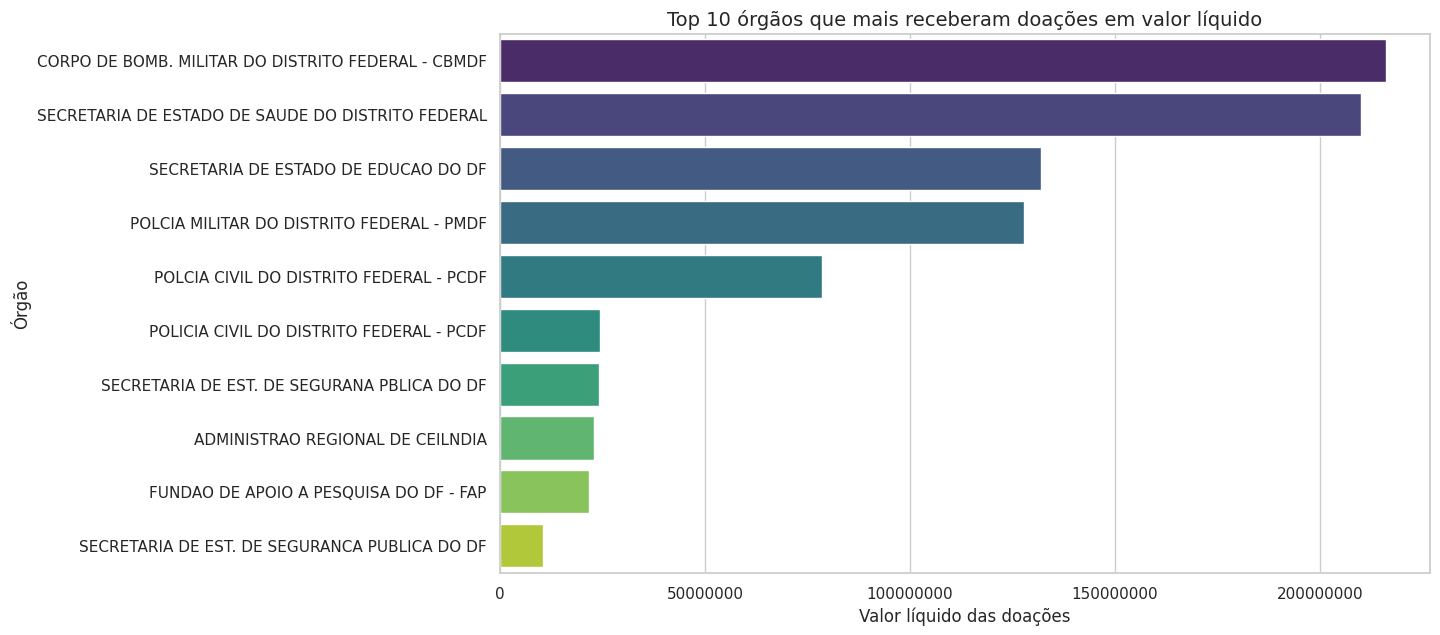


**Interpretação:**
O gráfico mostra os 10 órgãos que mais receberam doações em **valor líquido** no período de 2020 a 2026.
O uso de `VL_LIQUIDO`, calculado como `VL_CREDITO - VL_DEBITO`, permite considerar possíveis estornos, ajustes ou correções contábeis.
Assim, o ranking destaca as unidades gestoras com maior volume financeiro efetivamente incorporado ao patrimônio público no período analisado.


In [25]:
# ETAPA 5.5 - GRÁFICO DE BARRAS HORIZONTAIS
# Top 10 órgãos que mais receberam valor líquido

top_orgaos = (
    df_total
    .groupby("DS_UNIDADE_GESTORA_LIMPA", as_index=False)["VL_LIQUIDO"]
    .sum()
    .sort_values("VL_LIQUIDO", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_orgaos,
    x="VL_LIQUIDO",
    y="DS_UNIDADE_GESTORA_LIMPA",
    hue="DS_UNIDADE_GESTORA_LIMPA",
    palette="viridis",
    legend=False
)

plt.title("Top 10 órgãos que mais receberam doações em valor líquido")
plt.xlabel("Valor líquido das doações")
plt.ylabel("Órgão")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

display(Markdown("""
**Interpretação:**
O gráfico mostra os 10 órgãos que mais receberam doações em **valor líquido** no período de 2020 a 2026.
O uso de `VL_LIQUIDO`, calculado como `VL_CREDITO - VL_DEBITO`, permite considerar possíveis estornos, ajustes ou correções contábeis.
Assim, o ranking destaca as unidades gestoras com maior volume financeiro efetivamente incorporado ao patrimônio público no período analisado.
"""))

In [26]:
# ÓRGÃO QUE MAIS RECEBEU DOAÇÕES DURANTE A PANDEMIA
# Período considerado: 2020, 2021 e 2022
# Métrica: VL_LIQUIDO = VL_CREDITO - VL_DEBITO

df_pandemia = df_total[df_total["NR_ANO_STATUS"].isin([2020, 2021, 2022])]

orgaos_pandemia = (
    df_pandemia
    .groupby("DS_UNIDADE_GESTORA_LIMPA", as_index=False)
    .agg(
        valor_liquido=("VL_LIQUIDO", "sum"),
        quantidade_doacoes=("VL_LIQUIDO", "count")
    )
    .sort_values("valor_liquido", ascending=False)
)

orgao_mais_recebeu_pandemia = orgaos_pandemia.head(1)

orgao_mais_recebeu_pandemia

,DS_UNIDADE_GESTORA_LIMPA,valor_liquido,quantidade_doacoes
50,SECRETARIA DE ESTADO DE SAUDE DO DISTRITO FEDERAL,1.120727e+08,197


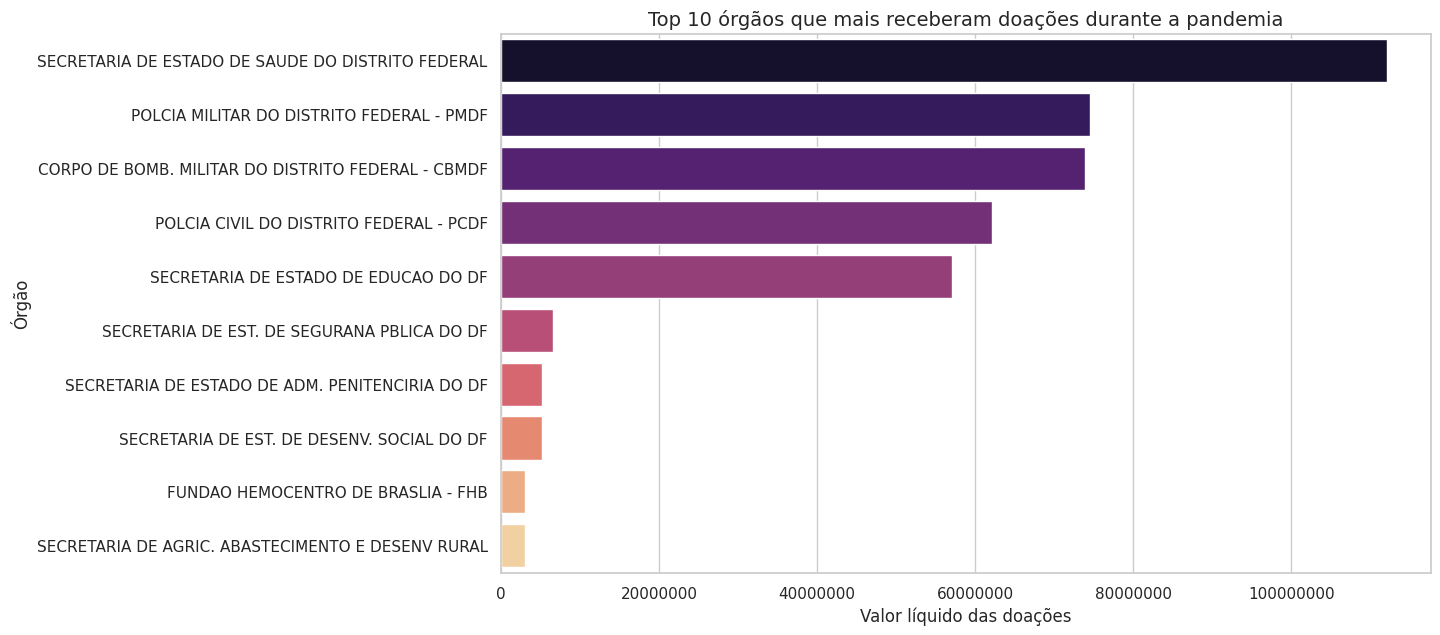


**Interpretação:**
O gráfico apresenta os órgãos que mais receberam doações em valor líquido durante o período de 2020 a 2022, associado aos efeitos da pandemia.
A métrica utilizada foi o `VL_LIQUIDO`, calculado pela diferença entre `VL_CREDITO` e `VL_DEBITO`, para considerar possíveis estornos e ajustes contábeis.
O órgão no topo do ranking representa a unidade gestora com maior volume financeiro líquido de doações no período analisado.


In [27]:
# ETAPA 5.6 - GRÁFICO - TOP 10 ÓRGÃOS DURANTE A PANDEMIA

top10_orgaos_pandemia = orgaos_pandemia.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top10_orgaos_pandemia,
    x="valor_liquido",
    y="DS_UNIDADE_GESTORA_LIMPA",
    hue="DS_UNIDADE_GESTORA_LIMPA",
    palette="magma",
    legend=False
)

plt.title("Top 10 órgãos que mais receberam doações durante a pandemia")
plt.xlabel("Valor líquido das doações")
plt.ylabel("Órgão")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

display(Markdown("""
**Interpretação:**
O gráfico apresenta os órgãos que mais receberam doações em valor líquido durante o período de 2020 a 2022, associado aos efeitos da pandemia.
A métrica utilizada foi o `VL_LIQUIDO`, calculado pela diferença entre `VL_CREDITO` e `VL_DEBITO`, para considerar possíveis estornos e ajustes contábeis.
O órgão no topo do ranking representa a unidade gestora com maior volume financeiro líquido de doações no período analisado.
"""))

In [28]:
# ETAPA 5.7 - TABELA - VOLUME DE DOACOES E VALOR LIQUIDO
# ANTES E DEPOIS DA QUARENTENA

def classificar_periodo_quarentena(ano):
    if ano in [2020, 2021, 2022]:
        return "Antes/durante a quarentena"
    elif ano in [2023, 2024, 2025, 2026]:
        return "Depois da quarentena"
    else:
        return "Fora do periodo analisado"


df_total["PERIODO_QUARENTENA"] = df_total["NR_ANO_STATUS"].apply(classificar_periodo_quarentena)

tabela_quarentena = (
    df_total
    .groupby("PERIODO_QUARENTENA")
    .agg(
        volume_doacoes=("VL_LIQUIDO", "count"),
        total_credito=("VL_CREDITO", "sum"),
        total_debito=("VL_DEBITO", "sum"),
        valor_liquido=("VL_LIQUIDO", "sum")
    )
    .reset_index()
)

tabela_quarentena

,PERIODO_QUARENTENA,volume_doacoes,total_credito,total_debito,valor_liquido
0,Antes/durante a quarentena,1651,4.856161e+08,6.974835e+07,4.158677e+08
1,Depois da quarentena,1780,7.308900e+08,2.128645e+08,5.180255e+08


In [29]:
tabela_quarentena_formatada = tabela_quarentena.copy()

for coluna in ["total_credito", "total_debito", "valor_liquido"]:
    tabela_quarentena_formatada[coluna] = tabela_quarentena_formatada[coluna].map(
        lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )

tabela_quarentena_formatada

,PERIODO_QUARENTENA,volume_doacoes,total_credito,total_debito,valor_liquido
0,Antes/durante a quarentena,1651,"R$ 485.616.087,18","R$ 69.748.353,90","R$ 415.867.733,28"
1,Depois da quarentena,1780,"R$ 730.890.046,27","R$ 212.864.520,33","R$ 518.025.525,94"


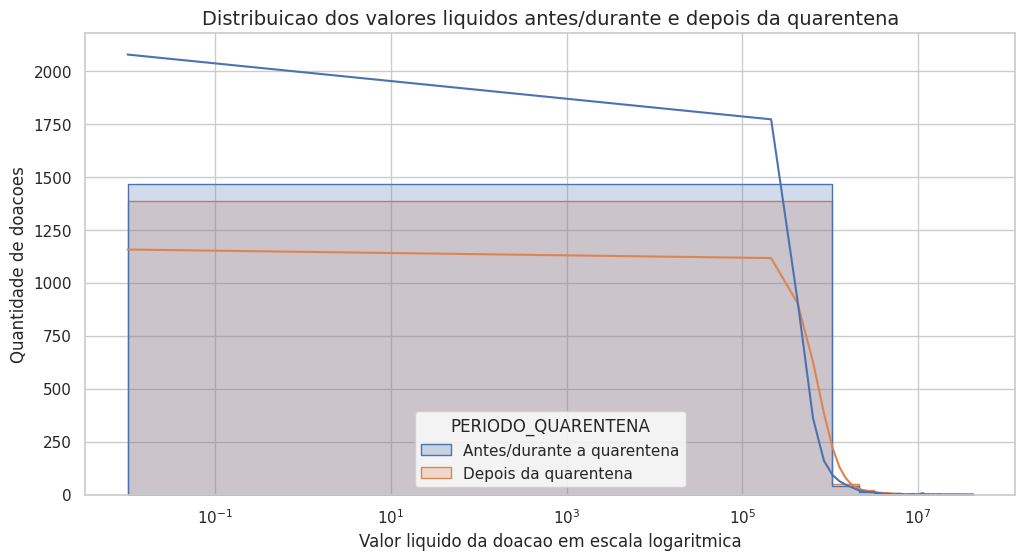


**Interpretação:**
Este histograma compara a distribuição dos valores líquidos das doações antes/durante e depois da quarentena.
A escala logarítmica permite visualizar melhor tanto as doações de menor valor quanto as de valor muito elevado.
A comparação entre os períodos ajuda a identificar se houve mudança no perfil dos valores das doações após a pandemia.


In [30]:
# ETAPA 5.8 - HISTOGRAMA - ANTES/DURANTE E DEPOIS DA QUARENTENA

df_hist_periodo = df_total[df_total["VL_LIQUIDO"] > 0].copy()

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_hist_periodo,
    x="VL_LIQUIDO",
    hue="PERIODO_QUARENTENA",
    bins=40,
    kde=True,
    element="step",
    stat="count",
    common_norm=False
)

plt.xscale("log")
plt.title("Distribuicao dos valores liquidos antes/durante e depois da quarentena")
plt.xlabel("Valor liquido da doacao em escala logaritmica")
plt.ylabel("Quantidade de doacoes")
plt.show()

display(Markdown("""
**Interpretação:**
Este histograma compara a distribuição dos valores líquidos das doações antes/durante e depois da quarentena.
A escala logarítmica permite visualizar melhor tanto as doações de menor valor quanto as de valor muito elevado.
A comparação entre os períodos ajuda a identificar se houve mudança no perfil dos valores das doações após a pandemia.
"""))

In [32]:
# GRAFICO - PERCENTUAL DE DEBITO SOBRE CREDITO POR ANO

resumo_anual_cd["percentual_debito"] = (
    resumo_anual_cd["total_debito"] / resumo_anual_cd["total_credito"]
) * 100

plt.figure(figsize=(12, 6))

sns.barplot(
    data=resumo_anual_cd,
    x="NR_ANO_STATUS",
    y="percentual_debito",
    color="darkorange",
    label="Debito sobre credito"
)

plt.title("Percentual de debito sobre credito por ano")
plt.xlabel("Ano")
plt.ylabel("Debito sobre credito (%)")
plt.legend()
plt.show()

display(Markdown("""
**Interpretação:**
Este gráfico mostra quanto os débitos representam em relação aos créditos de cada ano.
Percentuais mais altos indicam anos com maior presença de ajustes, estornos ou correções contábeis.
Essa análise é especialmente útil para interpretar anos em que o valor bruto das doações parece alto, mas o valor líquido final é reduzido pelos débitos.
"""))

NameError: name 'resumo_anual_cd' is not defined

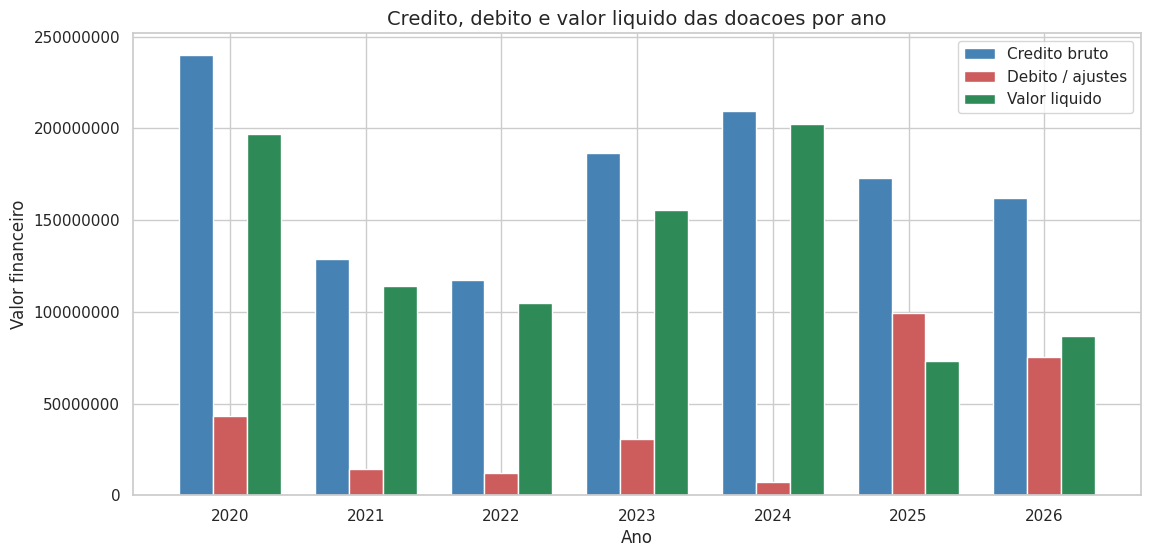


**Interpretação:**
O gráfico compara o crédito bruto, o débito e o valor líquido das doações por ano.
Essa visualização é importante porque mostra que o volume registrado como crédito não representa necessariamente o valor final incorporado ao patrimônio público.
Quando os débitos são elevados, o valor líquido pode ser bem menor que o crédito bruto, indicando possíveis estornos, ajustes ou correções contábeis.


In [33]:
# ETAPA 6 - RESUMO FINAL PARA APOIAR AS CONCLUSÕES
# GRAFICO - CREDITO, DEBITO E VALOR LIQUIDO POR ANO

resumo_anual_cd = (
    df_total
    .groupby("NR_ANO_STATUS", as_index=False)
    .agg(
        total_credito=("VL_CREDITO", "sum"),
        total_debito=("VL_DEBITO", "sum"),
        valor_liquido=("VL_LIQUIDO", "sum")
    )
    .sort_values("NR_ANO_STATUS")
)

plt.figure(figsize=(13, 6))

largura = 0.25
anos = np.arange(len(resumo_anual_cd["NR_ANO_STATUS"]))

plt.bar(
    anos - largura,
    resumo_anual_cd["total_credito"],
    width=largura,
    label="Credito bruto",
    color="steelblue"
)

plt.bar(
    anos,
    resumo_anual_cd["total_debito"],
    width=largura,
    label="Debito / ajustes",
    color="indianred"
)

plt.bar(
    anos + largura,
    resumo_anual_cd["valor_liquido"],
    width=largura,
    label="Valor liquido",
    color="seagreen"
)

plt.title("Credito, debito e valor liquido das doacoes por ano")
plt.xlabel("Ano")
plt.ylabel("Valor financeiro")
plt.xticks(anos, resumo_anual_cd["NR_ANO_STATUS"])
plt.legend()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

display(Markdown("""
**Interpretação:**
O gráfico compara o crédito bruto, o débito e o valor líquido das doações por ano.
Essa visualização é importante porque mostra que o volume registrado como crédito não representa necessariamente o valor final incorporado ao patrimônio público.
Quando os débitos são elevados, o valor líquido pode ser bem menor que o crédito bruto, indicando possíveis estornos, ajustes ou correções contábeis.
"""))

In [39]:
def classificar_periodo_pandemia(ano):
    if ano in [2020, 2021, 2022]:
        return "Pre/durante pandemia"
    elif ano in [2023, 2024, 2025, 2026]:
        return "Pos-pandemia"
    else:
        return "Fora do periodo"

df_total["PERIODO_PANDEMIA"] = df_total["NR_ANO_STATUS"].apply(classificar_periodo_pandemia)

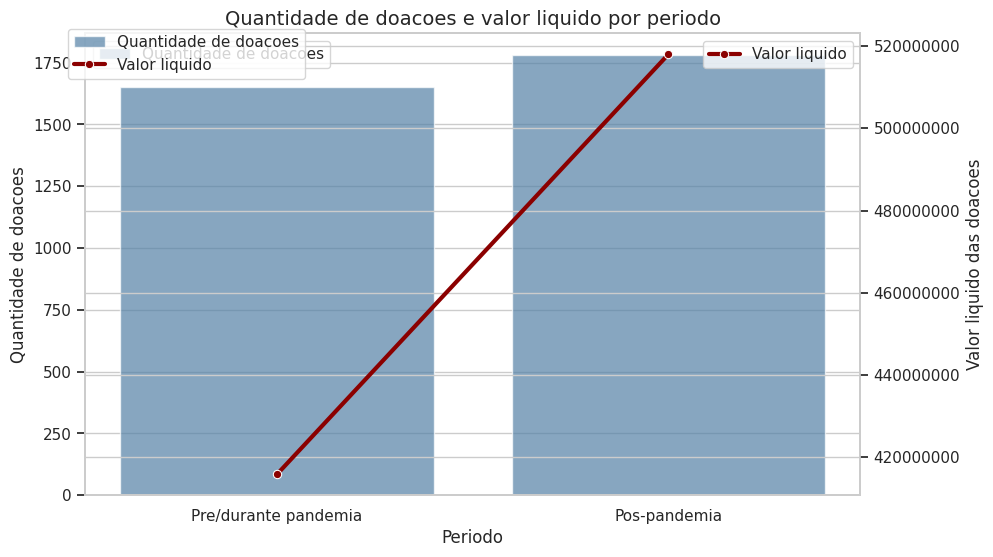


**Interpretacao:**  
O grafico compara a quantidade de doacoes e o valor liquido entre o periodo pre/durante pandemia e o periodo pos-pandemia. 
As barras representam o numero de registros de doacoes, enquanto a linha mostra o valor liquido calculado por `VL_CREDITO - VL_DEBITO`. 
Essa visualizacao permite observar se a mudanca entre os periodos ocorreu mais pela quantidade de doacoes, pelo valor financeiro liquido, ou por ambos.


In [42]:
# GRAFICO - QUANTIDADE DE DOACOES E VALOR LIQUIDO
# PRE/DURANTE PANDEMIA X POS-PANDEMIA

ordem_periodos = ["Pre/durante pandemia", "Pos-pandemia"]

resumo_periodo = (
    df_total
    .groupby("PERIODO_PANDEMIA", as_index=False)
    .agg(
        quantidade_doacoes=("VL_LIQUIDO", "count"),
        valor_liquido=("VL_LIQUIDO", "sum")
    )
)

resumo_periodo = resumo_periodo[
    resumo_periodo["PERIODO_PANDEMIA"].isin(ordem_periodos)
].copy()

resumo_periodo["ordem"] = resumo_periodo["PERIODO_PANDEMIA"].map({
    "Pre/durante pandemia": 0,
    "Pos-pandemia": 1
})

resumo_periodo = resumo_periodo.sort_values("ordem")

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=resumo_periodo,
    x="ordem",
    y="quantidade_doacoes",
    color="steelblue",
    alpha=0.7,
    ax=ax1,
    label="Quantidade de doacoes"
)

ax1.set_xlabel("Periodo")
ax1.set_ylabel("Quantidade de doacoes")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(ordem_periodos)

ax2 = ax1.twinx()

sns.lineplot(
    data=resumo_periodo,
    x="ordem",
    y="valor_liquido",
    color="darkred",
    marker="o",
    linewidth=3,
    ax=ax2,
    label="Valor liquido"
)

ax2.set_ylabel("Valor liquido das doacoes")
ax2.ticklabel_format(style="plain", axis="y")

plt.title("Quantidade de doacoes e valor liquido por periodo")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

display(Markdown("""
**Interpretacao:**
O grafico compara a quantidade de doacoes e o valor liquido entre o periodo pre/durante pandemia e o periodo pos-pandemia.
As barras representam o numero de registros de doacoes, enquanto a linha mostra o valor liquido calculado por `VL_CREDITO - VL_DEBITO`.
Essa visualizacao permite observar se a mudanca entre os periodos ocorreu mais pela quantidade de doacoes, pelo valor financeiro liquido, ou por ambos.
"""))